# Optic flow task


This notebook illustrates the optic flow task and how to use it with our pretrained fly visual system model and decoder.

**Select GPU runtime**

To run the notebook on a GPU select Menu -> Runtime -> Change runtime type -> GPU.

In [ ]:
# @markdown **Check access to GPU**

try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if True:
    import torch

    try:
        cuda_name = torch.cuda.get_device_name()
        print(f"Name of the assigned GPU / CUDA device: {cuda_name}")
    except RuntimeError:
        import warnings

        warnings.warn(
            "You have not selected Runtime Type: 'GPU' or Google could not assign you one. Please revisit the settings as described above or proceed on CPU (slow)."
        )

**Install Flyvis**

The notebook requires installing our package `flyvis`. You may need to restart your session after running the code block below with Menu -> Runtime -> Restart session. Then, imports from `flyvis` should succeed without issue.

In [ ]:
# @markdown **Install Flyvis**
if IN_COLAB:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]

# The Sintel dataset

We use the Sintel dataset to train our models as described in the paper. More infos about the Sintel dataset can be found on the official Sintel website: http://sintel.is.tue.mpg.de/.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.analysis.animations.sintel import SintelSample
from flyvis.datasets.FT3D import MultiTaskFlyingThings3D


The class `MultiTaskSintel` loads, preprocesses, renders, and augments the sintel data. It adheres to the pytorch dataset primitive. It provides the interface to the input data and the output data for the flyvis networks. Note: the fly-eye rendering we use here, we introduce in the notebook on creating custom stimuli already.

This is the full setting:

In [2]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    # Because the fly eye rendering is square
    # and sintel is wide, we can crop sintel
    # in width and render three sequences from one.
    # This allows us to statically augment our dataset
    # a bit already before we proceed with the random augmentations.
    # We end up with 3 * 23 sequences.
    vertical_splits=3,
    n_frames=19,
    center_crop_fraction=0.7,
    dt=1 / 50,
    augment=True,
    # From sequences with more than n_frames, we randomly sample the start frame.
    random_temporal_crop=True,
    all_frames=False,
    # We resample movie frames to the effective framerate given by 1/dt
    resampling=True,
    # We interpolate the flow arrows to 1/dt.
    interpolate=True,
    # We flip with equal probability (using one flip-axis).
    p_flip=0.5,
    flip_axes=[0, 1],
    # We rotate with equal probability (using five fold rotation symmetry of the hex-grid).
    p_rot=5 / 6,
    # We randomly adjust contrast and brightness.
    contrast_std=0.2,
    brightness_std=0.1,
    # We add random white noise pixelweise.
    gaussian_white_noise=0.08,
    gamma_std=None,
    _init_cache=True,
    unittest=False,
)
import os
from pathlib import Path
FT3D_ROOT      = Path(os.getenv("FT3D_ROOT", "/mnt/s/datasets/FlyingThings3D"))
augment = True
dataset_custom = MultiTaskFlyingThings3D(
        ft3d_path=FT3D_ROOT,
        tasks=["lum", "flow"],
        augment=augment,
        _init_cache=True,
    )

[2025-06-10 10:05:38] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [3]:
# The `dataset.arg_df` tracks the sequence index, identity etc.
#dataset.arg_df
dataset_custom.arg_df

,index,original_index,name,original_n_frames
0,0,0,sequence_00000_A_0000_split_00,9
1,1,0,sequence_00000_A_0000_split_01,9
2,2,0,sequence_00000_A_0000_split_02,9
3,3,1,sequence_00001_A_0001_split_00,9
4,4,1,sequence_00001_A_0001_split_01,9
...,...,...,...,...
4255,4255,2237,sequence_02237_C_0748_split_01,9
4256,4256,2237,sequence_02237_C_0748_split_02,9
4257,4257,2238,sequence_02238_C_0749_split_00,9
4258,4258,2238,sequence_02238_C_0749_split_01,9


## Single sample

First, let's chunk this into smaller digestable pieces.

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    dt=1 / 24,
    augment=False,
)

The first sample. For the target, the pixel-accurate motion vectors, the color indicates the direction of motion of the respective input pixel. The saturation indicates the magnitude of motion.

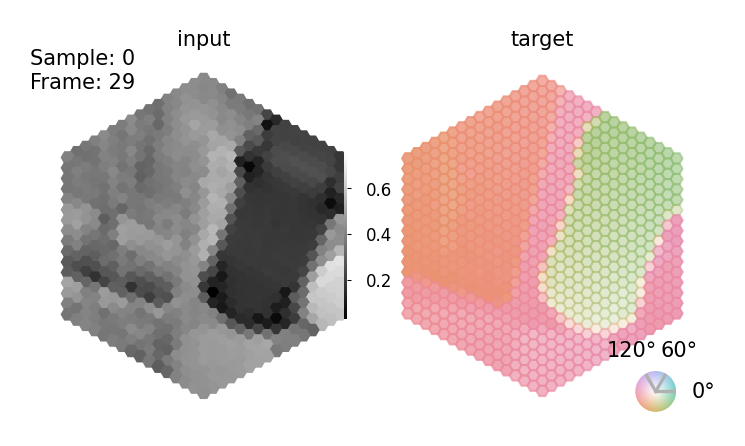

In [5]:
#lum = dataset[0]["lum"]
#flow = dataset[0]["flow"]

#animation = SintelSample(lum[None], flow[None])
#animation.animate_in_notebook()

lum = dataset_custom[2]["lum"]
flow = dataset_custom[2]["flow"]

animation = SintelSample(lum[None], flow[None])
animation.animate_in_notebook()


Sintel has more groundtruth annotations. We support depth and flow because we know with some confidence that these are relevant for the fly.

In [6]:
dataset = MultiTaskSintel(
    tasks=["depth"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    dt=1 / 24,
    augment=False,
)

[2025-06-10 10:08:53] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet
[2025-06-10 10:08:53] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [9]:
lum1 = dataset[0]["lum"]
depth1 = dataset[0]["depth"]

#animation = SintelSample(lum1[None], depth1[None])

#animation.animate_in_notebook()
dataset.arg_df

,index,original_index,name,original_n_frames
0,0,0,sequence_00_alley_1_split_00,50
1,1,1,sequence_01_alley_2_split_00,50
2,2,2,sequence_02_ambush_2_split_00,21
3,3,3,sequence_03_ambush_4_split_00,33
4,4,4,sequence_04_ambush_5_split_00,50
5,5,5,sequence_05_ambush_6_split_00,20
6,6,6,sequence_06_ambush_7_split_00,50
7,7,7,sequence_07_bamboo_1_split_00,50
8,8,8,sequence_08_bamboo_2_split_00,50
9,9,9,sequence_09_bandage_1_split_00,50


# Augmenting the dataset step-by-step

We apply rich augmentations to the dataset of naturalistic sequences because the dataset is otherwise relatively small. This might lead to overfitting to, e.g., predicting motion mostly into well-represented directons or of objects of specific contrasts etc. Using rich augmentations, we 'ask' the network to generalize better and invariantly compute motion regardless of direction, contrast, brightness, pixel noise, temporal appearance etc.

## Vertical splits

First, we split each sequence into three sequences vertically to leverage a wider extent of the video than if we would only render the center. We precompute these renderings.

In [ ]:
from flyvis.analysis.visualization.plots import quick_hex_scatter

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    dt=1 / 24,
    augment=False,
)

Sintel has 23 movie sequences originally.

In [ ]:
len(np.unique(dataset.arg_df.original_index))

Each original sequence is 436 pixel in height times 1024 pixel in width in cartesian coordinates.

With the vertical crops, we end up with 3 * 23 sequences. The `dataset.arg_df` tracks the sequence index, identity etc.

In [ ]:
dataset.arg_df

In [ ]:
sequence_default = dataset.cartesian_sequence(5, vertical_splits=1, center_crop_fraction=1.0)
flow_default = dataset.cartesian_flow(5, vertical_splits=1, center_crop_fraction=1.0)

t = 5  # Frame index
frame = sequence_default[0, t]
flow = flow_default[0, t]           # shape: (2, H, W)
flow = np.moveaxis(flow, 0, -1)     # → (H, W, 2)
flow_mag = np.linalg.norm(flow, axis=-1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Frame
axs[0].imshow(frame, cmap='binary_r')
axs[0].set_title(f"Input Frame {t}")
axs[0].axis('off')

# Flow magnitude
im = axs[1].imshow(flow_mag, cmap='inferno')
axs[1].set_title(f"Flow Magnitude — Frame {t}")
axs[1].axis('off')
fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
flow_custom = normalized_ft3d.cartesian_flow(0, vertical_splits=1, center_crop_fraction=1.0)
frame =flow_custom[0, 0]            # (540, 960, 2)

flow_mag = np.linalg.norm(frame, axis=2)   # (540, 960)

plt.figure(figsize=(8, 6))
plt.imshow(flow_mag, cmap='inferno', origin='upper')
plt.colorbar(label='Flow magnitude')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3)
_ = quick_hex_scatter(dataset[0]['lum'][0].flatten(), fig=fig, ax=axes[0], cbar=False)
_ = quick_hex_scatter(dataset[1]['lum'][0].flatten(), fig=fig, ax=axes[1], cbar=False)
_ = quick_hex_scatter(dataset[2]['lum'][0].flatten(), fig=fig, ax=axes[2], cbar=False)

## Random temporal crops

We train on 19 frames ~ 792ms movie. Most sequences have 49 frames. To use the whole temporal content, we stochastically sample start and end frame ~ ((1, 19), (2, 20), ..., (31, 49)).

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=True,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=0,
    p_rot=0,
    contrast_std=None,
    brightness_std=None,
    gaussian_white_noise=None,
)

In [ ]:
# These two samples from the same original sequence should have stochastically different start and end frames.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

In [ ]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

## Flips and rotations

Next, we flip stochastically across 2 axes and or rotate a random number of times around the center. We implement this to be fast to do so at runtime.

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=False,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=1 / 2,
    p_rot=5 / 6,
    contrast_std=None,
    brightness_std=None,
    gaussian_white_noise=None,
)

In [ ]:
# These two samples from the same original sequence should have stochastically different orientation.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

In [ ]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

Flow vectors need to be flipped and rotated accordingly.

In [ ]:
# These two samples from the same original sequence should have stochastically different orientation.
data = dataset[0]
lum1 = data['lum']
flow1 = data['flow']

In [ ]:
animation = SintelSample(lum1[None], flow1[None])
animation.animate_in_notebook()

## Further augmentations

Besides that, we also augment the input with random contrasts and brightnesses and random gaussian pixel noise, while the motion stays the same. This pretends that the same motion takes place under different illumination conditions and signal to noise ratios.  

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=False,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=0,
    p_rot=0,
    contrast_std=0.2,
    brightness_std=0.1,
    gaussian_white_noise=0.08,
)

In [ ]:
# These two samples from the same original sequence have
# stochastically different contrast, brightness and pixel-wise noise.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

In [ ]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

# Framerate of the dataset and integration time step

The Sintel dataset is originally rendered at 24 frames per second, i.e., one frame every 42ms. The fruit fly neurons are able to respond to temporal differences as fast as 5-20ms. Therefore, we resample every frame multiple times to pretend that the movie was originally sampled at such a faster framerate. For the motion fields, we interpolate flow vectors in time instead of resampling them, which hopefully gives a better learning signal to the network. We have to trade-off speed of the numerical integration and memory consumption during optimization with the simulation accuracy by choosing time steps between 5-20ms. We chose to train networks at the upper bount of 20ms and evaluate them more accurately at 5-10ms.

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)


In [ ]:
# Now, every input frame appears twice and target frames are interpolated.
data = dataset[0]
lum1 = data['lum']
flow1 = data['flow']

In [ ]:
animation = SintelSample(lum1[None], flow1[None])
animation.animate_in_notebook()

# Computing responses to the Sintel data

Before we get to training a network, we look at a few responses to these type of sequences of individual neurons.

In [ ]:
from flyvis.network import NetworkView, Network
from flyvis.utils.activity_utils import LayerActivity

from flyvis.datasets.sintel import MultiTaskSintel

In [ ]:
# new network instance
network = Network()

# Alternative: uncomment to use a pretrained network
# network_view = NetworkView(results_dir / "flow/0000/000")
# network = network_view.init_network(network)

In [ ]:
layer_activity = LayerActivity(None, network.connectome, keepref=True)

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)
dataset = dataset1

In [ ]:
stationary_state = network.fade_in_state(1.0, dataset.dt, dataset[0]["rgb"][[0]])
responses = network.simulate(
    dataset[0]["rgb"][None], dataset.dt, initial_state=stationary_state
).cpu()

In [ ]:
plt.figure(figsize=[3, 2])
layer_activity.update(responses)
r = layer_activity.central.T4c.squeeze().numpy()
time = np.arange(0, r.shape[0], 1) * dataset.dt
plt.plot(time, r)
plt.xlabel("time in s")
plt.ylabel("voltage (a.u.)")
plt.title("response of central T4c cell")

# Decoding the task from neural activity

We need to predict the pixel-accurate flow field that Sintel gives us. For that we decode the voltages of a bunch of cell types. The decoder and the network are trained end-to-end. Here an example of a forward pass through the whole pipeline in code.

In [ ]:
network = Network()

In [ ]:
decoder = DecoderGAVP(network.connectome, shape=[8, 2], kernel_size=5)

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    all_frames=True,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

In [ ]:
data = dataset[0]
lum = data["lum"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)

In [ ]:
y_pred = decoder(responses)

In [ ]:
data = dataset[0]
lum = data["lum"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)
animation = SintelSample(lum[None], flow[None], prediction=y_pred.detach().cpu())
animation.animate_in_notebook(frames=np.arange(lum.shape[0])[::10])

We predict motion with an untrained decoder from an untrained network with randomly initialized parameters. 
We do not expect this to work.

In [ ]:
data = dataset1[0]
lum = data["rgb"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)
animation = SintelSample(lum[None], flow[None], prediction=y_pred.detach().cpu())
#animation.animate_in_notebook(frames=np.arange(lum.shape[0])[::10])
#animation = SintelSample(lum[None], flow[None])
animation.animate_in_notebook()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.datasets.FT3D import MultiTaskFlyingThings3D
import os
from pathlib import Path
import torch

# ───── Load datasets ─────
sintel = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

FT3D_ROOT = Path(os.getenv("FT3D_ROOT", "/mnt/s/datasets/FlyingThings3D"))
ft3d = MultiTaskFlyingThings3D(
    ft3d_path=FT3D_ROOT,
    tasks=["lum", "flow"],
    augment=True,
    _init_cache=True,
)

# ───── Helper to extract all magnitudes ─────
def get_all_magnitudes(dataset, key="flow"):
    all_mags = []
    for i in range(len(dataset)):
        flow = dataset[i][key].cpu().numpy()
        mags = np.linalg.norm(flow.reshape(-1, 2), axis=-1)
        all_mags.append(mags)
    return np.concatenate(all_mags)

# ───── Compute magnitude stats ─────
mags_ft3d = get_all_magnitudes(ft3d, key="flow")
mags_sintel = get_all_magnitudes(sintel, key="flow")

mag_95 = np.percentile(mags_ft3d, 95)
print(f"95th percentile of FT3D flow magnitude: {mag_95:.4f}")

# ───── Apply normalization to sample ─────
flow_sample = ft3d[15]["flow"].cpu().numpy()
flow_normalized = flow_sample / mag_95 *100

# ───── Plot comparison ─────
plt.hist(np.linalg.norm(flow_normalized.reshape(-1, 2), axis=1), bins=100, alpha=0.5, label="FT3D (95%-normalized)")
plt.hist(mags_sintel, bins=100, alpha=0.5, label="Sintel")
plt.yscale("log")
plt.legend()
plt.title("Flow Magnitude Distributions (FT3D normalized vs Sintel)")
plt.xlabel("Flow Magnitude")
plt.ylabel("Frequency (log scale)")
plt.grid(True)
plt.show()


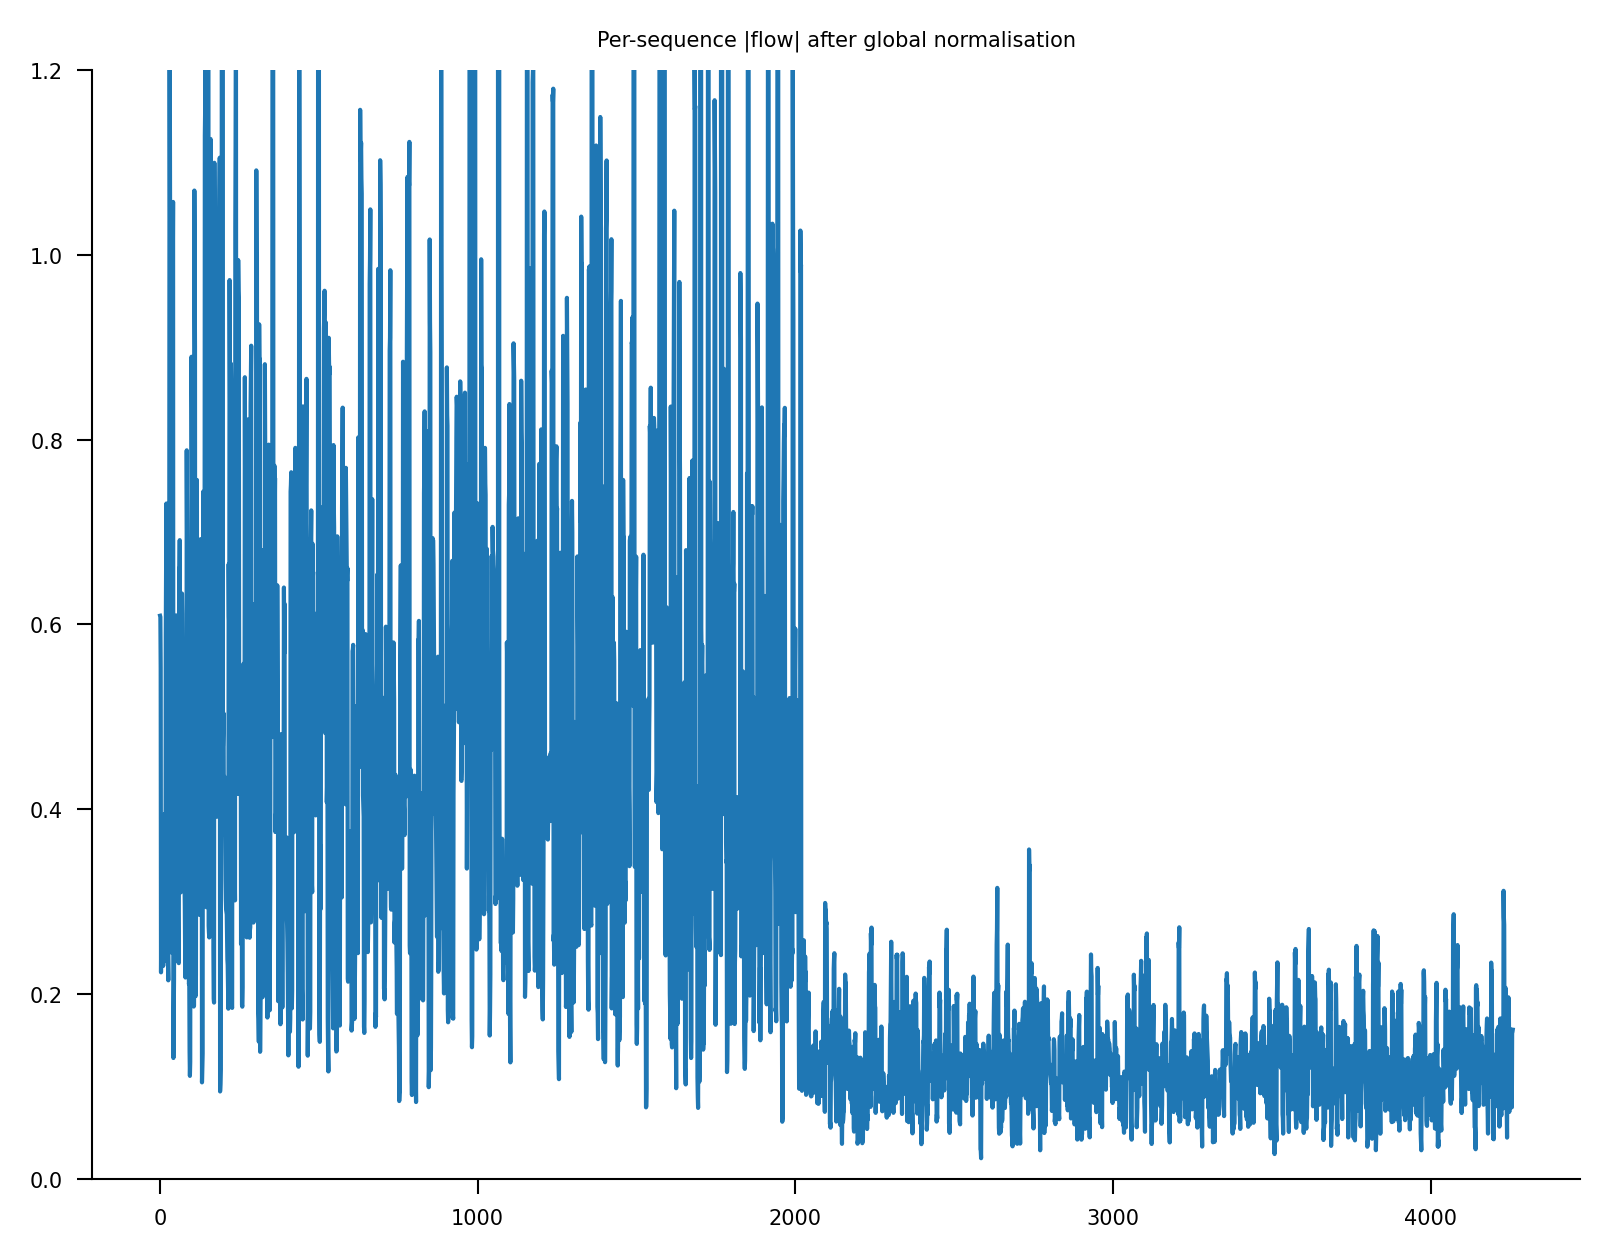

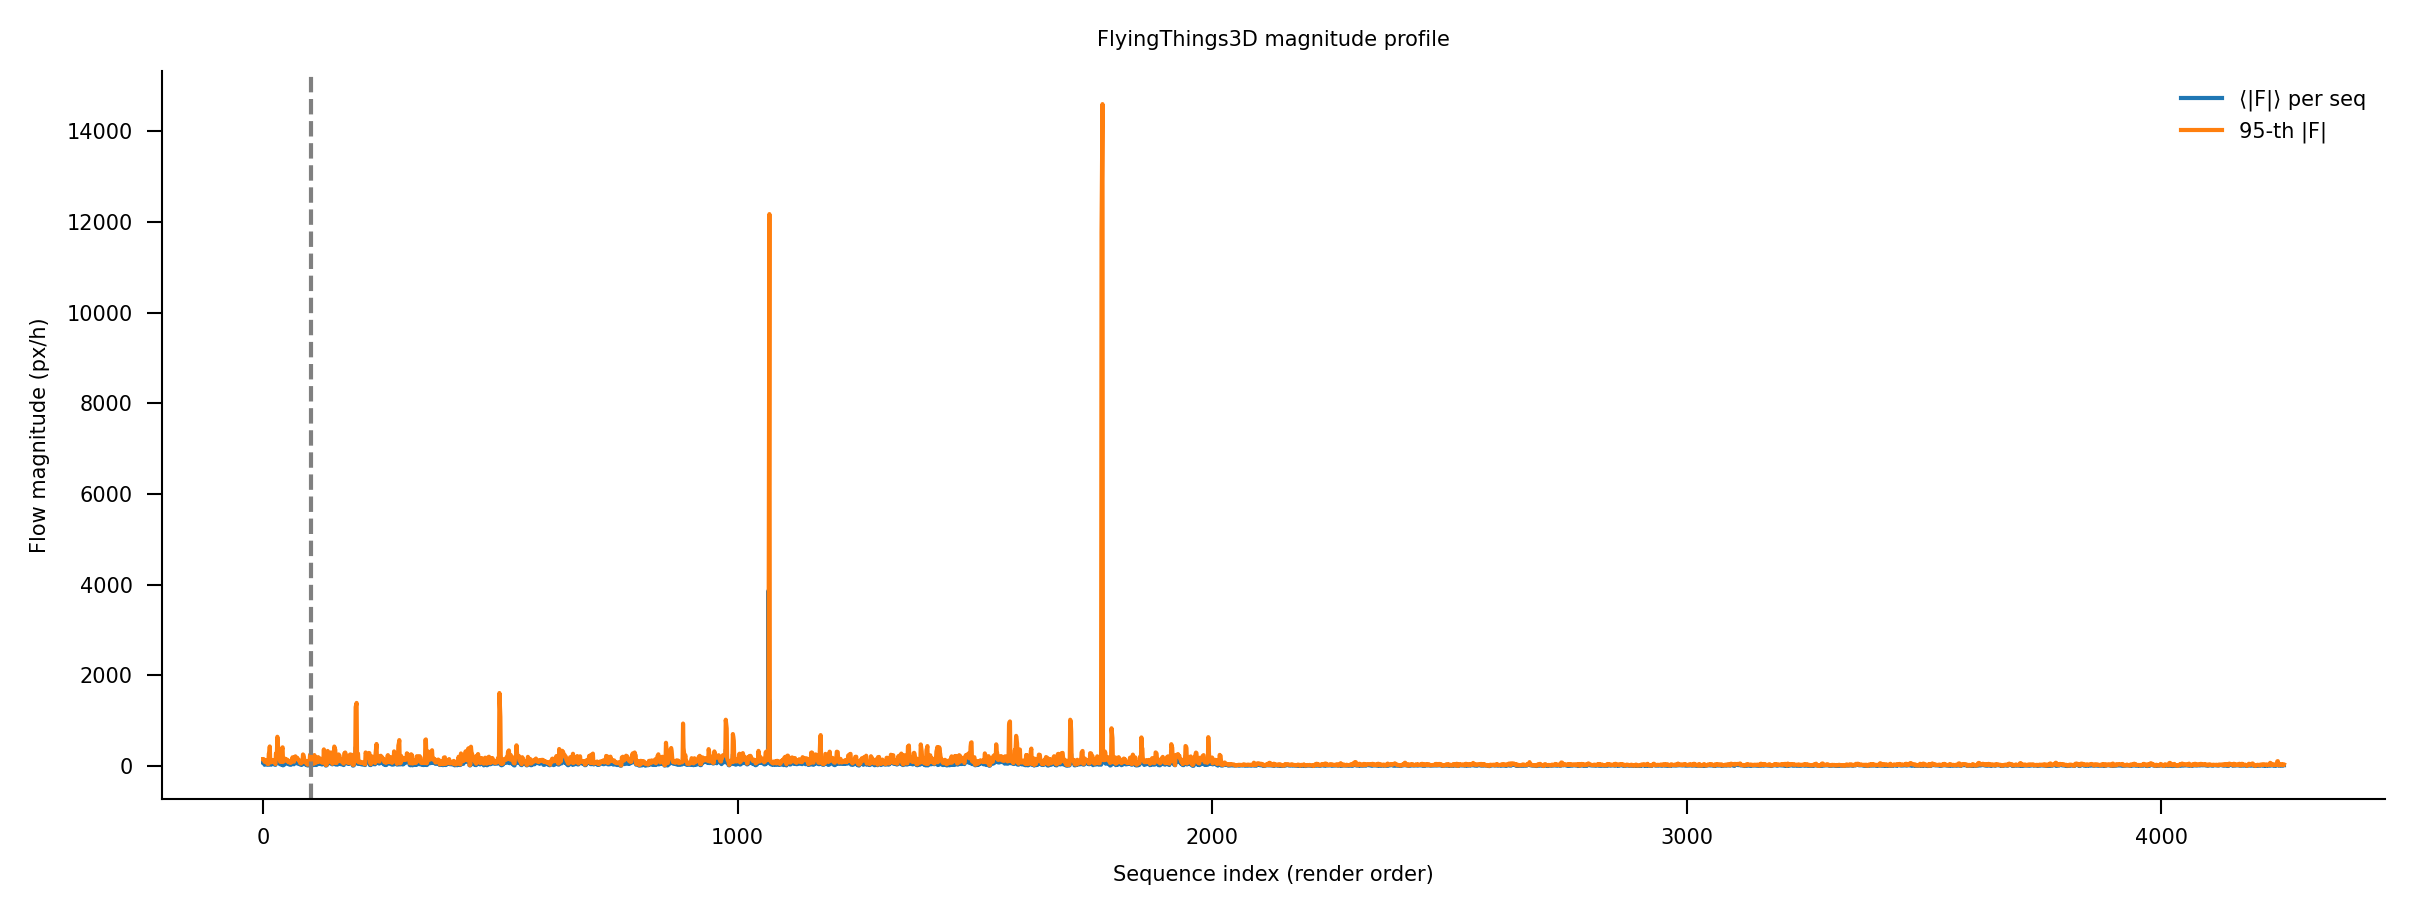

In [18]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from flyvis.datasets.FT3D import MultiTaskFlyingThings3D
train_loader = DataLoader(
    normalized_ft3d,
    batch_size=16,
    shuffle=True,
    num_workers=4,
)

stats_norm = []
for i in range(len(normalized_ft3d)):
    flow = normalized_ft3d[i]["flow"]
    mags = torch.linalg.vector_norm(flow, dim=1)
    stats_norm.append(mags.mean().item())

plt.plot(stats_norm); plt.ylim(0, 1.2)
plt.title("Per-sequence |flow| after global normalisation")
plt.show()


# 3. quick visual
plt.figure(figsize=(8,3))
plt.plot(stats.mag_mean,  label="⟨|F|⟩ per seq")
plt.plot(stats.mag_p95,   label="95-th |F|")
plt.axvline(100, ls='--', lw=1, c='gray')
plt.xlabel("Sequence index (render order)"); plt.ylabel("Flow magnitude (px/h)")
plt.title("FlyingThings3D magnitude profile"); plt.legend(); plt.tight_layout()
plt.show()


In [19]:
# 1.  See which original folder each plotted point refers to
for i in [1895, 1900, 1905]:
    print(i, ft3d.arg_df.name[i])          # needs arg_df from init_cache

# 2.  Compare average magnitude by group letter
groups = {}
for name in ft3d.arg_df.name:
    grp = name.split('_')[2]              # A / B / C
    groups.setdefault(grp, []).append(name)
print({g: len(v) for g, v in groups.items()})

# 3.  Mean |flow| for first 100 and last 100 sequences
def seq_mean(idx):
    mag = torch.linalg.vector_norm(ft3d[idx]['flow'], dim=1)
    return mag.mean().item()
print(np.mean([seq_mean(i) for i in range(100)]))
print(np.mean([seq_mean(i) for i in range(len(ft3d)-100, len(ft3d))]))


1895 sequence_00701_A_0705_split_02
1900 sequence_00704_A_0708_split_01
1905 sequence_00706_A_0710_split_00
{'A': 2019, 'C': 2241}
61.985610752105714
17.723037400245666


# Training network and decoder on a single batch

We now train the network on a single batch to validate that the pipeline works. We do not expect these networks to generalize their function.

In [2]:
from tqdm.notebook import tqdm
from torch.optim import Adam
from torch.utils.data import DataLoader
import torch
from flyvis.network import Network
from flyvis.task.decoder import DecoderGAVP
from flyvis.task.mc_decoder import DecoderTinyRes
from flyvis.analysis.animations.sintel import SintelSample
import matplotlib.pyplot as plt
from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.task.objectives import l2norm, epe
from copy import deepcopy
from flyvis.connectome import *
from flyvis.network.network import Network
from flyvis.task.decoder import DecoderGAVP
import os
from flyvis.datasets.FT3D import MultiTaskFlyingThings3D
from flyvis.datasets.FT3D import RenderedFlyingThings3D
from pathlib import Path
import numpy as np
import yaml
from flyvis import results_dir
from flyvis import renderings_dir
from pathlib import Path
from flyvis.datasets.FT3D import RenderedFlyingThings3D
from torch.utils.data import Subset
sintel = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

FT3D_ROOT      = Path(os.getenv("FT3D_ROOT", "/mnt/s/datasets/FlyingThings3D"))
augment = True
ft3d = MultiTaskFlyingThings3D(
        ft3d_path=FT3D_ROOT,
        tasks=["lum", "flow"],
        augment=augment,
        interpolate=True,  resampling=False,
        _init_cache=True,
    )

half_len   = len(ft3d) // 2                  # integer division → first 50 %
half_idx   = range(half_len,len(ft3d))                 # 0 … half_len-1
ft3d  = Subset(ft3d, half_idx)


# 1⃣  Grab defaults and make an editable copy
base_cfg = deepcopy(Network().config)

base_cfg.edge_config.syn_strength.groupby =[
                "source_type", "target_type",
                "source_index", "target_index",
            ]
net_custom = Network(
    node_config=base_cfg.node_config,
    edge_config=base_cfg.edge_config,    # keep the rest unchanged
    connectome=base_cfg.connectome,
    dynamics=base_cfg.dynamics,
    stimulus_config=base_cfg.stimulus_config,
)
decoder_custom  = DecoderGAVP(net_custom.connectome, shape=[32,16,2], kernel_size=5)





[2025-06-10 10:15:50] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet
[2025-06-10 10:16:52] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.
[2025-06-10 10:16:56] network:222 Initialized network with NumberOfParams(free=1513361, fixed=2959) parameters.
[2025-06-10 10:16:58] decoder:282 Initialized decoder with NumberOfParams(free=41347, fixed=0) parameters.
[2025-06-10 10:16:58] decoder:283 DecoderGAVP(
  (base): Sequential(
    (0): Conv2dHexSpace(34, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Softplus(beta=1.0, threshold=20.0)
    (3): Dropout(p=0.5, inplace=False)
    (4): Conv2dHexSpace(32, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Softplus(beta=1.0, threshold=20.0)
    (7): Dropout(p=0.5, inplace=False)
  )
 

In [8]:
net_default = Network()

[2025-06-10 09:22:11] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


In [3]:
def get_all_magnitudes(dataset, key="flow"):
    all_mags = []
    for i in range(len(dataset)):
        flow = dataset[i][key].cpu().numpy()
        mags = np.linalg.norm(flow.reshape(-1, 2), axis=-1)
        all_mags.append(mags)
    return np.concatenate(all_mags)

mags_ft3d = get_all_magnitudes(ft3d, key="flow")
mag_95 = np.percentile(mags_ft3d, 95)  # scalar

# ───── Wrapper that normalizes "flow" by mag_95 → [0,100] ─────
class FT3DNormalized(torch.utils.data.Dataset):
    def __init__(self, base_dataset, mag_95):
        self.base    = base_dataset
        self.mag_95  = mag_95

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        sample = self.base[idx].copy()            # don’t modify original
        sample["flow"] = sample["flow"] / self.mag_95
        return sample

    # ---- helper wrappers now also normalise ----
    def cartesian_flow(self, *args, **kwargs):
        flow = self.base.cartesian_flow(*args, **kwargs)
        return flow / self.mag_95

    def cartesian_sequence(self, *args, **kwargs):
        return self.base.cartesian_sequence(*args, **kwargs)


normalized_ft3d = FT3DNormalized(ft3d, mag_95)


In [4]:

t_pre = 0.5
dt = 1 / 50
batch_size = 16
train_loader = DataLoader(ft3d, batch_size=batch_size,drop_last=True)
lr= 1e-3


In [5]:
torch.cuda.empty_cache()         # clears *cached* but not live memory
torch.cuda.ipc_collect()         # optional: clears inter-process handles
import gc

gc.collect()
a = torch.zeros(300000000, dtype=torch.int8)
a = a.cuda()
del a
torch.cuda.empty_cache()


In [6]:
loss_fn = epe
initial_state_custom  = net_custom.steady_state(t_pre, dt, batch_size)


In [13]:
epochs = 500                                    # ← any number you like
def grad_stats(model: torch.nn.Module) -> float:
    g = [p.grad.abs().mean() for p in model.parameters() if p.grad is not None]
    return torch.stack(g).mean().item() if g else 0.
    


# ── set-up (same as before) ────────────────────────────────────────────
errors_custom = []


opt_custom  = Adam((*net_custom.parameters(),  *decoder_custom.parameters()),  lr=lr)

# ── training loop with nice tqdm output ───────────────────────────────
for e in range(epochs):
    pb = tqdm(train_loader, desc=f"Epoch {e+1}/{epochs}", leave=False,miniters=50)  # one bar per epoch
    epoch_loss_custom  = 0.0
    epoch_loss_default = 0.0

    for lum, flow in ((b["lum"], b["flow"]) for b in pb):
        # zero & feed input
        opt_custom.zero_grad();  net_custom.stimulus.zero();  net_custom.stimulus.add_input(lum)

        # forward
        act_cust  = net_custom(net_custom.stimulus(),  dt=1/50, state=initial_state_custom)
        y_cust    = decoder_custom(act_cust)

        # loss & back-prop
        loss_cust = loss_fn(y_cust, flow);   
        loss_cust.backward();                
        opt_custom.step();                   
   
        epoch_loss_custom  += loss_cust.item()
        pb.set_postfix({
            "batch_cust": f"{loss_cust.item():.4f}",
        })
        #if e % 1 == 0:  # debug every epoch
        #    print(f"ep{e:02d}  "
        #        f"mean|grad| net={grad_stats(net_custom):.2e}  "
        #        f"dec={grad_stats(decoder_custom):.2e}  "
        #        f"loss={loss_cust.item():.4f}")

    # epoch means
    epoch_loss_custom  /= len(train_loader)
    errors_custom.append(epoch_loss_custom)

    pb.write(f"Epoch {e+1:>3}: custom={epoch_loss_custom:.4f}")


plt.figure(figsize=(8,4))
plt.plot(errors_custom,  label="net_custom",   alpha=0.5)
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Loss (EPE)")
plt.title("Training curves"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

torch.save(net_custom.state_dict(), "net_custom_weights_500.pth")
torch.save(decoder_custom.state_dict(), "decoder_custom_weights_500.pth")


Epoch 1/500:   0%|          | 0/133 [00:00<?, ?it/s]

KeyboardInterrupt: 

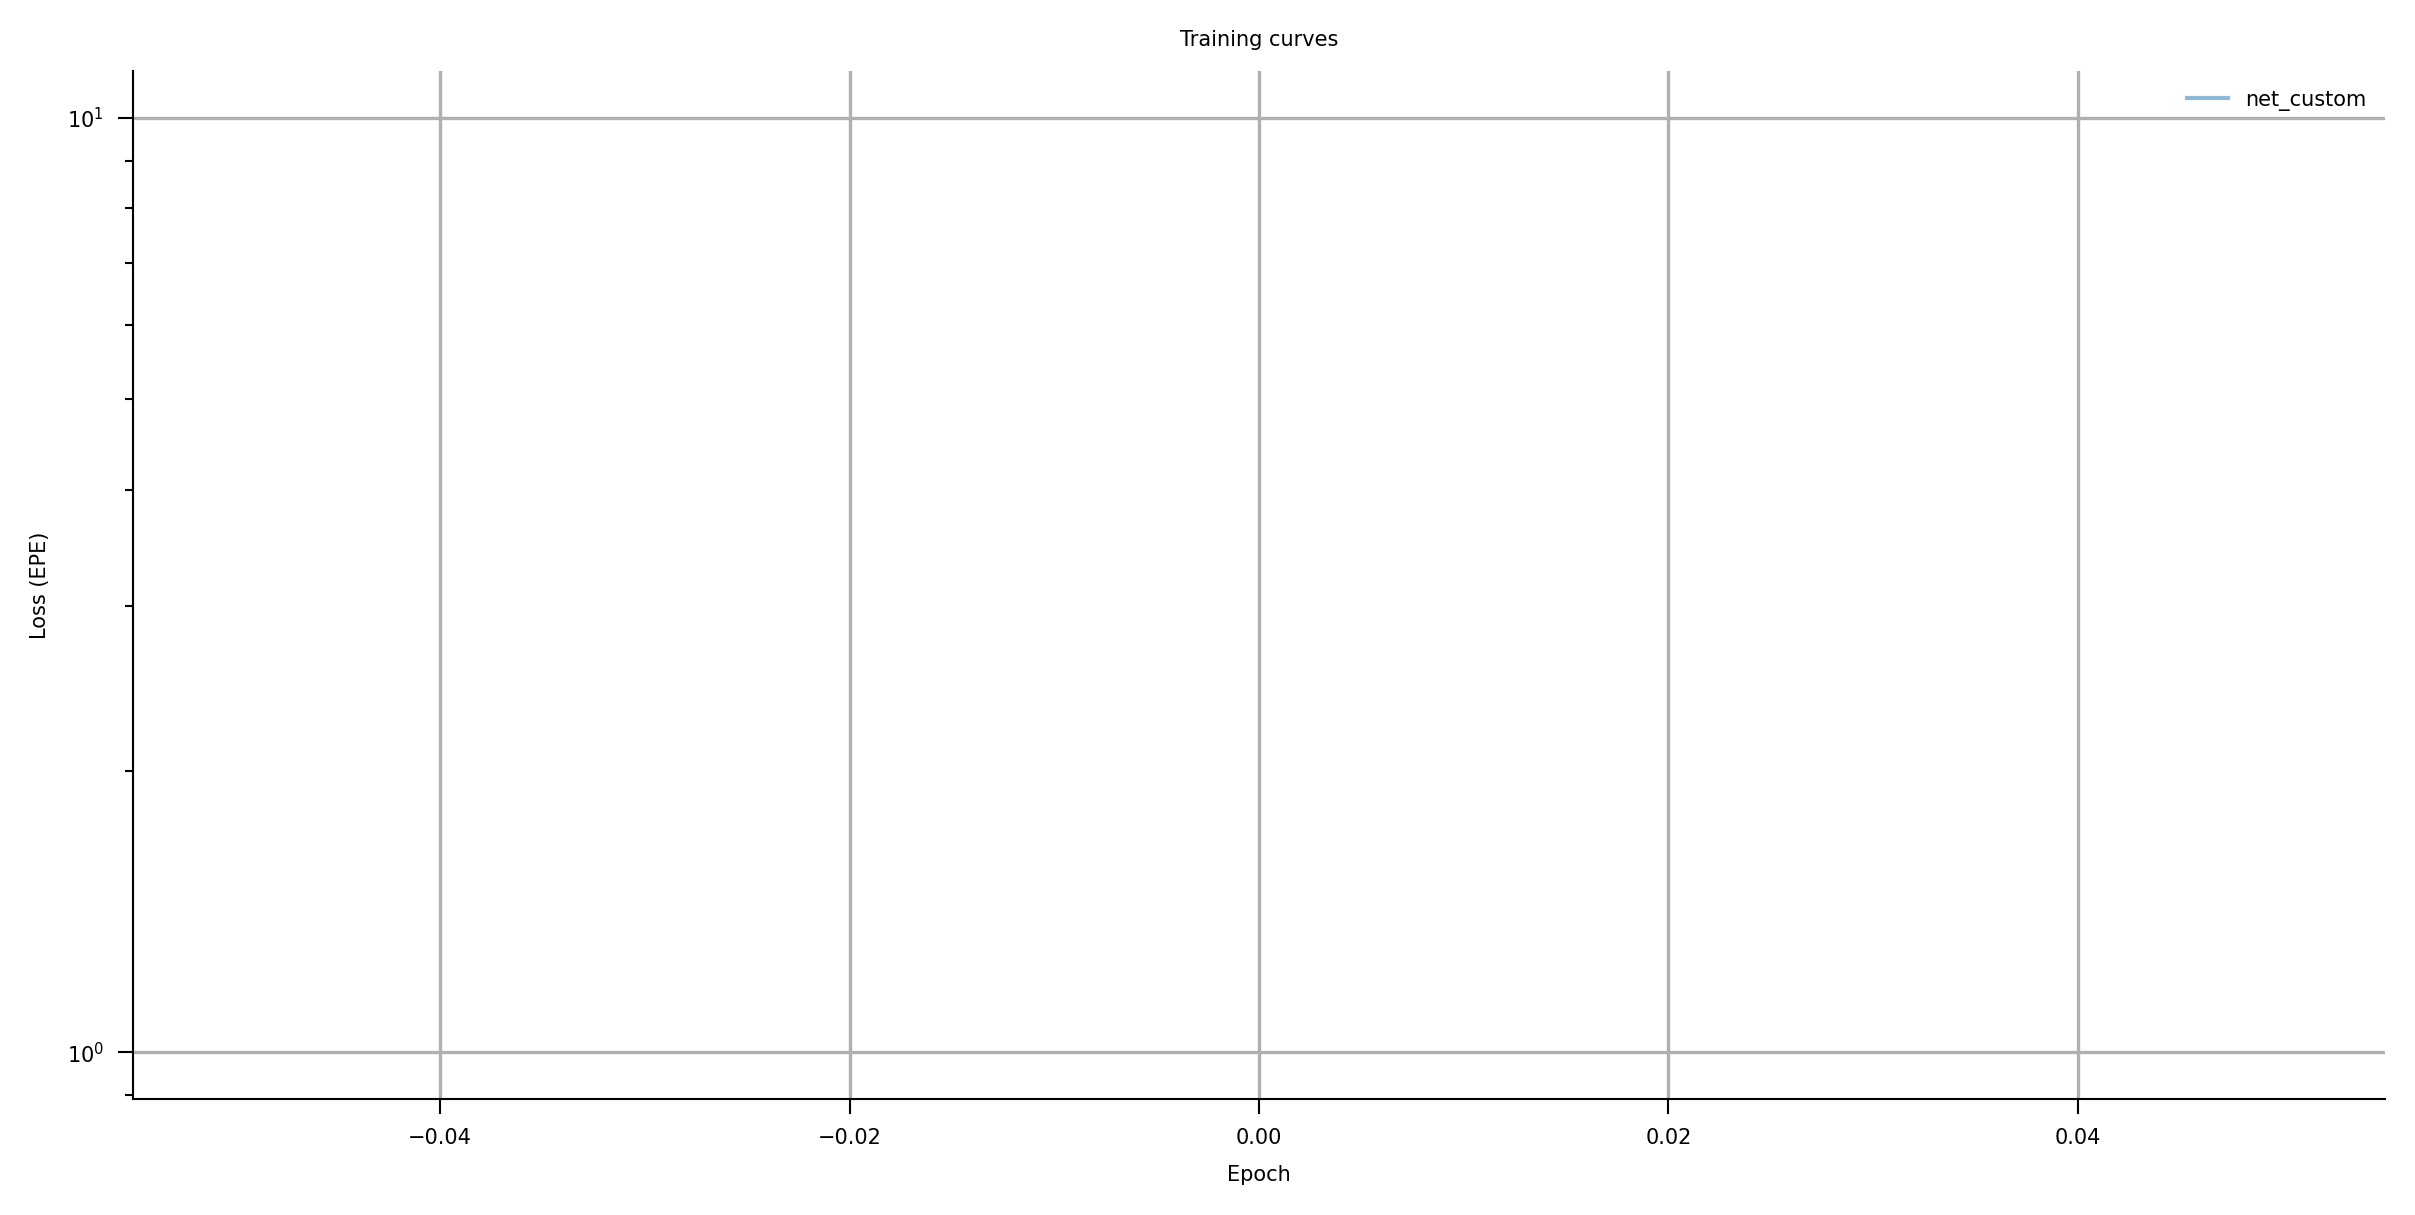

In [ ]:


plt.figure(figsize=(8,4))
plt.plot(errors_custom,  label="net_custom",   alpha=0.5)
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Loss (EPE)")
plt.title("Training curves"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


In [14]:
net_custom.load_state_dict(torch.load("net_custom_weights.pth",
                                      map_location="cpu"))     # or "cuda:0"
decoder_custom.load_state_dict(torch.load("decoder_custom_weights.pth",
                                          map_location="cpu"))


<All keys matched successfully>

In [22]:
batch = next(iter(train_loader))
seq = 10
lum = batch["lum"]   # Remove batch dimension
flow= batch["flow"][seq] # Remove batch dimension

net_custom.stimulus.zero()
net_custom.stimulus.add_input(lum)
activity_custom = net_custom(net_custom.stimulus(), dt=1/50, state=initial_state_custom)
y_pred_custom = decoder_custom(activity_custom)
print(y_pred_custom.shape,)
#net_default.stimulus.zero()
#net_default.stimulus.add_input(lum)
#activity_default = net_default(net_default.stimulus(), dt=1/50, state=initial_state_default)

#y_pred_default = decoder_default(activity_default)

lum = batch["lum"][seq]   # Remove batch dimension
flow = batch["flow"][seq] # Remove batch dimension
pred = y_pred_custom[seq,:,:,:]
animation = SintelSample(lum[None], flow[None], prediction=pred[None].detach().cpu())
animation.animate_in_notebook()


OutOfMemoryError: CUDA out of memory. Tried to allocate 94.00 MiB. GPU 0 has a total capacity of 7.78 GiB of which 85.25 MiB is free. Including non-PyTorch memory, this process has 7.68 GiB memory in use. Of the allocated memory 7.33 GiB is allocated by PyTorch, and 214.86 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [17]:
print(y_pred_custom.shape,flow.shape)
((y_pred_custom[:,1:,:,:] - flow[1:,:,:]) ** 2).sqrt().mean()

torch.Size([16, 30, 2, 721]) torch.Size([30, 2, 721])


tensor(10.0998, device='cuda:0', grad_fn=<MeanBackward0>)

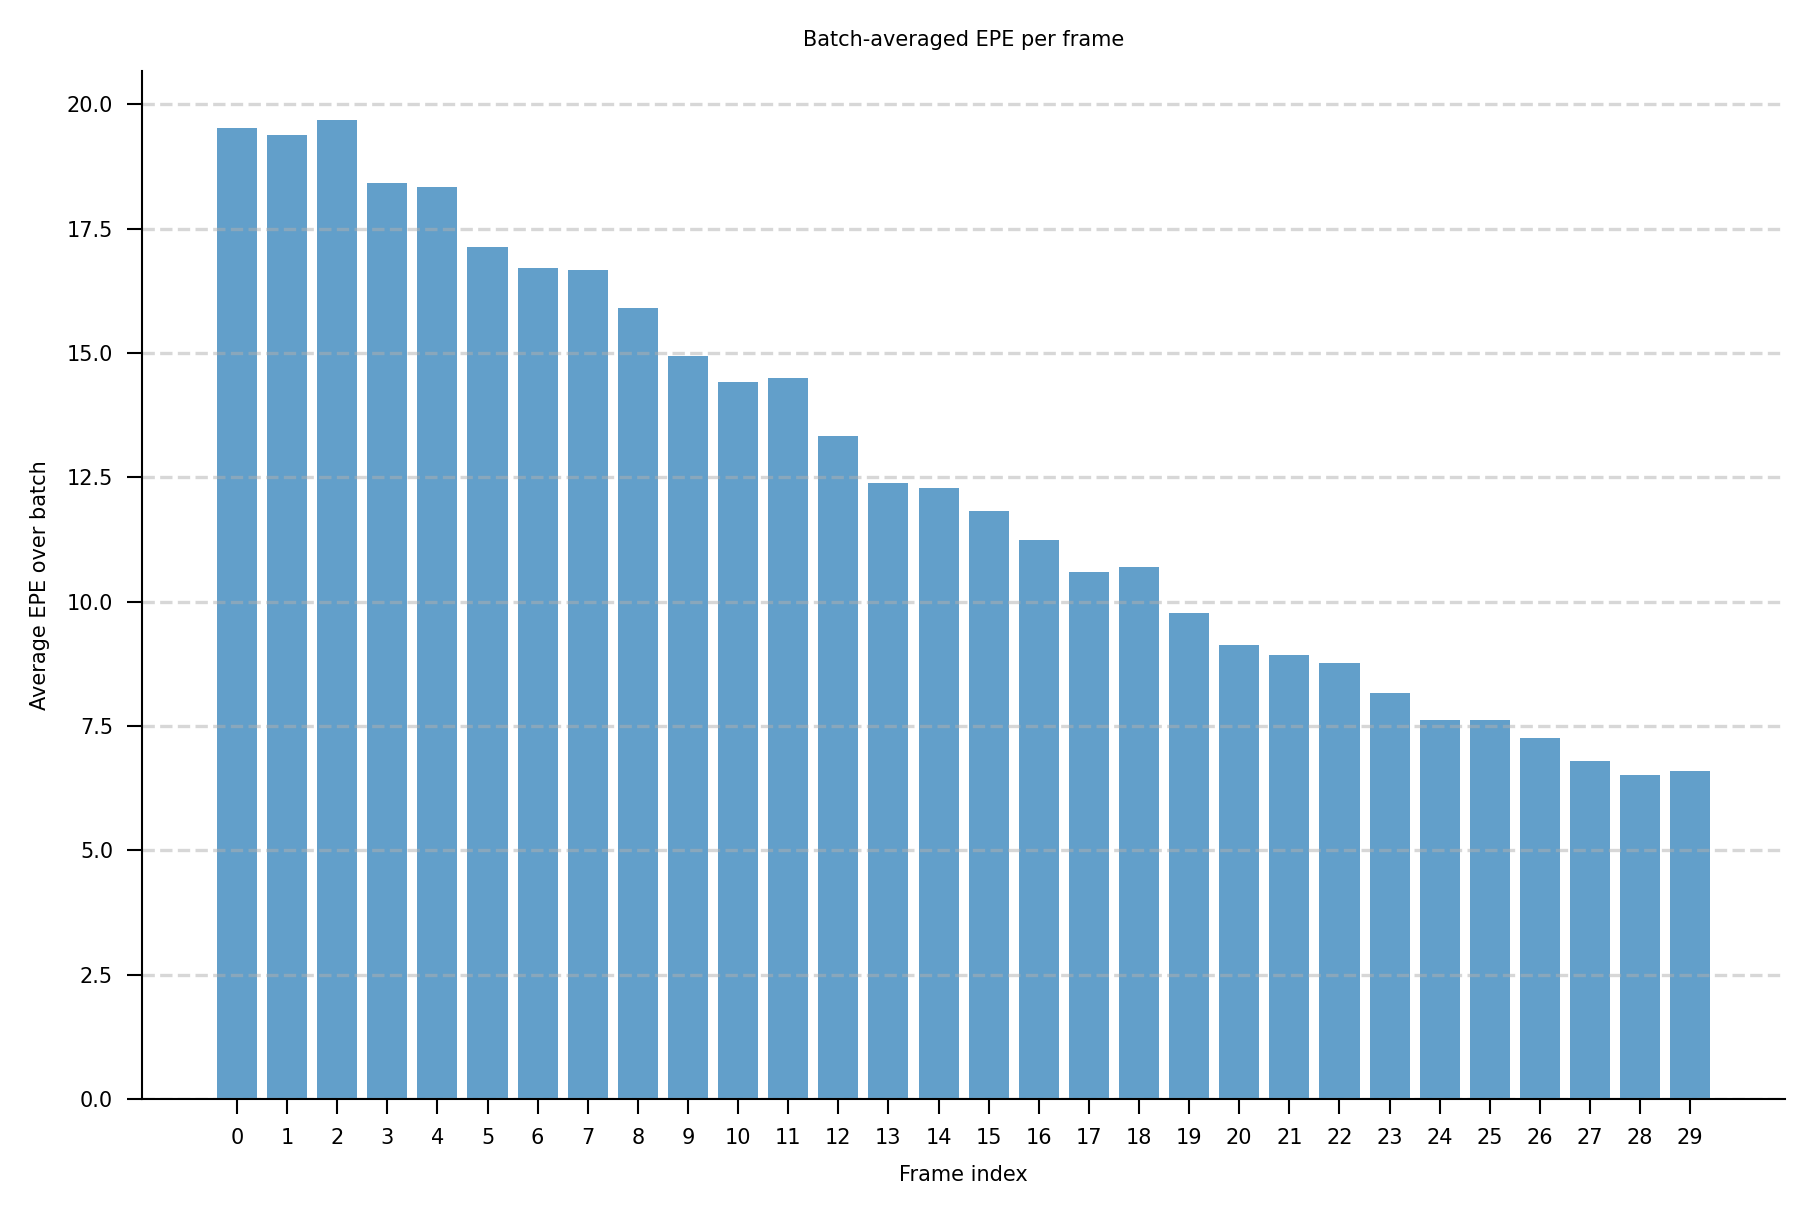

In [19]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_all = y_pred_custom.detach().cpu().numpy()  # (B, T, 2, 721)
gt_all     = batch["flow"].detach().cpu().numpy()  # (B, T, 2, 721)

B, T, _, _ = y_pred_all.shape

# Pre‐allocate
errors_per_frame = np.zeros(T)

for t in range(T):
    # diff_t: shape (B, 2, 721)
    diff_t = y_pred_all[:, t, :, :] - gt_all[:, t, :, :]
    # mag_t: shape (B, 721), since axis=1 reduces the "2"-dim into per‐pixel norm
    mag_t = np.linalg.norm(diff_t, axis=1)   # <-- axis=1, not axis=0
    # Now average over all pixels (dim=1) and all batch entries
    errors_per_frame[t] = mag_t.mean()

plt.figure(figsize=(6, 4))
plt.bar(np.arange(T), errors_per_frame, alpha=0.7)
plt.xlabel("Frame index")
plt.ylabel("Average EPE over batch")
plt.title("Batch‐averaged EPE per frame")
plt.xticks(np.arange(T))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
torch.save(net_custom.state_dict(), "net_custom_weights.pth")

torch.save(decoder_custom.state_dict(), "decoder_custom_weights.pth")

In [ ]:
def run():
            
    epochs = 500                                    # ← any number you like
    def grad_stats(model: torch.nn.Module) -> float:
        g = [p.grad.abs().mean() for p in model.parameters() if p.grad is not None]
        return torch.stack(g).mean().item() if g else 0.
        


    # ── set-up (same as before) ────────────────────────────────────────────
    errors_custom, errors_default = [], []

    initial_state_custom  = net_custom.steady_state(t_pre, dt, batch_size)
    initial_state_default = net_default.steady_state(t_pre, dt, batch_size)

    decoder_custom  = DecoderGAVP(net_custom.connectome, shape=[8, 2], kernel_size=5)
    decoder_default = DecoderGAVP(net_default.connectome, shape=[8, 2], kernel_size=5)

    opt_custom  = Adam((*net_custom.parameters(),  *decoder_custom.parameters()),  lr=lr)
    opt_default = Adam((*net_default.parameters(), *decoder_default.parameters()), lr=lr)

    # ── training loop with nice tqdm output ───────────────────────────────
    for e in range(epochs):
        pb = tqdm(train_loader, desc=f"Epoch {e+1}/{epochs}", leave=False,miniters=50)  # one bar per epoch
        epoch_loss_custom  = 0.0
        epoch_loss_default = 0.0

        for lum, flow in ((b["lum"], b["flow"]) for b in pb):
            # zero & feed input
            opt_custom.zero_grad();  net_custom.stimulus.zero();  net_custom.stimulus.add_input(lum)
            opt_default.zero_grad(); net_default.stimulus.zero(); net_default.stimulus.add_input(lum)

            # forward
            act_cust  = net_custom(net_custom.stimulus(),  dt=1/50, state=initial_state_custom)
            act_def   = net_default(net_default.stimulus(), dt=1/50, state=initial_state_default)
            y_cust    = decoder_custom(act_cust)
            y_def     = decoder_default(act_def)

            # loss & back-prop
            loss_cust = loss_fn(y_cust, flow);   loss_def = loss_fn(y_def, flow)
            loss_cust.backward();                loss_def.backward()
            opt_custom.step();                   opt_default.step()
    
            epoch_loss_custom  += loss_cust.item()
            epoch_loss_default += loss_def.item()
            pb.set_postfix({
                "batch_cust": f"{loss_cust.item():.4f}",
                "batch_def":  f"{loss_def.item():.4f}"
            })
            if e % 1 == 0:  # debug every epoch
                print(f"ep{e:02d}  "
                    f"mean|grad| net={grad_stats(net_custom):.2e}  "
                    f"dec={grad_stats(decoder_custom):.2e}  "
                    f"loss={loss_cust.item():.4f}")

        # epoch means
        epoch_loss_custom  /= len(train_loader)
        epoch_loss_default /= len(train_loader)
        errors_custom.append(epoch_loss_custom)
        errors_default.append(epoch_loss_default)

        pb.write(f"Epoch {e+1:>3}: custom={epoch_loss_custom:.4f} | default={epoch_loss_default:.4f}")
    # ── plot after training (unchanged) ───────────────────────────────────
    plt.figure(figsize=(8,4))
    plt.plot(errors_default, label="net (default)", alpha=0.5)
    plt.plot(errors_custom,  label="net_custom",   alpha=0.5)
    plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Loss (EPE)")
    plt.title("Training curves"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


    torch.save(net_custom.state_dict(), "net_custom_weights.pth")
    torch.save(decoder_custom.state_dict(), "decoder_custom_weights.pth")
    torch.save(net_default.state_dict(), "net_default_weights.pth")
    torch.save(decoder_default.state_dict(), "decoder_default_weights.pth")

In [11]:
# ── imports ───────────────────────────────────────────────────────────
import os, math, imageio.v2 as imageio
import numpy as np
import torch, matplotlib.pyplot as plt
from contextlib import nullcontext

# ── Deep-Dream movie helper ───────────────────────────────────────────
# ── helper to detect the sensory / input nodes ─────────────────────────
def _count_input_elements(connectome) -> int:
    """Return how many pixels (hexals) feed the network.

    Strategy
    --------
    1. Look for a node column that labels sensory cells
       (common names: 'role', 'type', 'class', 'celltype').
    2. Fallback: nodes with zero in-degree (no afferent synapses)."""
    import numpy as np, pandas as pd

    nodes = connectome.nodes                  # pandas.DataFrame
    edges = connectome.edges                  # pandas.DataFrame

    # 1) semantic labels ------------------------------------------------
    tag_cols = ["role", "type", "class", "celltype", "ctype"]
    sensory_keywords = ("input", "sensory", "pr", "photoreceptor")

    for col in tag_cols:
        if col in nodes.columns:
            mask = nodes[col].astype(str).str.lower().str.contains(
                "|".join(sensory_keywords), na=False
            )
            if mask.any():
                return int(mask.sum())

    # 2) structural fallback -------------------------------------------
    indeg = np.bincount(edges.target_index, minlength=len(nodes))
    return int((indeg == 0).sum())


# ── robust Deep-Dream movie helper ─────────────────────────────────────
def deep_dream_movie(
    net,
    *,
    dt: float = 1 / 100,
    n_steps: int = 100,
    interval: int = 2,
    lr: float = 1e-2,
    target_neurons=None,
    movie_shape: tuple | None = None,     # (H, W); guessed if None
    seed: int = 0,
    sigma_init: float = 0.05,
    save_file: str = "dream_movie.mp4",
):
    """
    Optimises a learnable movie for `n_steps` and writes an MP4
    that shows the *first* stimulus frame every `interval` steps.
    """
    import math, os, imageio.v2 as imageio, numpy as np
    import torch, matplotlib.pyplot as plt

    torch.manual_seed(seed)
    net.eval()

    # how many input pixels? -------------------------------------------
    n_hex = len(net.stimulus.input_index) 

    # decide on a 2-D layout for visualisation -------------------------
    if movie_shape is None:
        side = int(round(math.sqrt(n_hex)))
        movie_shape = (side, side) if side * side == n_hex else (1, n_hex)

    # learnable stimulus tensor ----------------------------------------
    n_frames = 32
# option A – wrap in nn.Parameter  (simplest)
    dream = torch.nn.Parameter(torch.randn(1, n_frames, 1, n_hex) * sigma_init)
    opt   = torch.optim.Adam([dream], lr=lr)

    # objective --------------------------------------------------------
    if target_neurons is None:
        def objective(state):                # maximise global activity
            return state.nodes.activity.mean()
    else:
        idx = torch.as_tensor(target_neurons)
        def objective(state):
            return state.nodes.activity[:, idx].pow(2).mean()

    # writer -----------------------------------------------------------
    os.makedirs(os.path.dirname(save_file) or ".", exist_ok=True)
    writer = imageio.get_writer(save_file, fps=max(1, round(1 / interval)))

    def _snap(step: int):
        with torch.no_grad():
            frame = dream[0, 0, 0].clamp(0, 1).cpu().view(*movie_shape).numpy()

        fig = plt.figure(figsize=(3, 3), dpi=120)
        ax  = fig.add_axes([0, 0, 1, 1]); ax.axis("off")
        ax.imshow(frame, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"step {step}", fontsize=7, color="white")
        fig.canvas.draw()
        writer.append_data(np.asarray(fig.canvas.buffer_rgba())[..., :3])
        plt.close(fig)

    # initial snapshot -------------------------------------------------
    _snap(0)

    # optimisation loop ------------------------------------------------
    for step in range(1, n_steps + 1):
        opt.zero_grad()
        dream.data.clamp_(0, 1)              # keep within luminance range

        states = net.simulate(dream, dt, as_states=True)
        loss   = -objective(states[-1])      # ascent
        loss.backward();  opt.step()

        if step % interval == 0:
            _snap(step)

    writer.close()
    print(f"[✓] wrote {save_file} ({n_steps // interval + 1} frames)")


# ── usage example ─────────────────────────────────────────────────────
# assumes you already defined/loaded `net_custom`
deep_dream_movie(
    net_custom,
    dt = 1/50,            # same dt as training
    n_steps = 100,
    interval = 2,         # frame every 2 steps ⇒ ~50 frames
    movie_shape = None,   # or (height, width)
    save_file = "dream_movie.mp4",
)


[2025-06-10 10:46:08] _io:561 IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (360, 360) to (368, 368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


RuntimeError: input has shape torch.Size([1, 32, 1, 8]) but buffer has shape torch.Size([1, 32, 45669])